# Multivariate Regression: Retail Sales, Income, and the Labor Market (PROC VARMAX)

## Executive Summary

U.S. retail sales and real disposable income move together month to
month, and both bend to the labor market. This notebook fits a **VARX**
-- a vector autoregression with an exogenous driver -- that lets the
two spending-and-income series explain each other while the change in
the unemployment rate enters as an outside force.

The headline result: a one-point rise in the monthly change of the
unemployment rate cuts retail-sales growth by about **2 percentage
points**, while measured disposable-income growth *rises* by about
**0.9 points** -- the fingerprint of automatic stabilizers cushioning
take-home income exactly when the job market weakens. Both effects are
estimated jointly and are strongly significant.

The model is fit by least squares (`METHOD=LS`), so each equation is
an ordinary regression -- the estimator most references report.

## Data Sources

| Series | FRED ID | Frequency | Transform | Role |
|---|---|---|---|---|
| Advance Retail Sales | `RSAFS` | Monthly | 100 x log-diff | endogenous |
| Real Disposable Personal Income | `DSPIC96` | Monthly | 100 x log-diff | endogenous |
| Unemployment Rate | `UNRATE` | Monthly | first difference | exogenous |

The committed snapshot `retail_x.csv` holds the three transformed
series over 1992-02 through 2024-12 (395 monthly observations). It is a
fixed pull from the Federal Reserve's FRED service, so the notebook
runs offline and reproducibly. The same data backs regression test
`71020`, which cross-checks the coefficients below against R's `vars`
package.

## The Idea: Endogenous vs. Exogenous

A VARX splits the variables by the role you want them to play. The
series on the **left** of the `MODEL` statement are *endogenous*: each
gets its own equation and feeds back on the others. The series on the
**right**, after the `=`, are *exogenous*: taken as given, they explain
the system without the system explaining them.

Here retail-sales growth and income growth are endogenous -- they
plausibly drive each other -- while the change in unemployment is
exogenous, since a single month of consumer spending does little to
move the national unemployment rate but the labor market moves
spending a great deal. Fitting both equations together also yields the
residual covariance, which a pair of separate regressions would miss.

## Step 1 - Load and inspect the series

Read the committed snapshot and confirm the three transformed series
are stationary and sensibly scaled before modeling.

In [1]:
proc means data="retail_x.csv" n mean std min max
           maxdec=3;
    var dlsales dlincome dunrate;
run;

                                                  The MEANS Procedure

 Variable         N           Mean     Std Dev     Minimum     Maximum
 ---------------------------------------------------------------------
 dlsales        395          0.381       1.742     -15.513      17.652
 dlincome       395          0.221       1.832     -16.374      20.615
 dunrate        395         -0.008       0.576      -2.200      10.400
 ---------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Both growth series average a few tenths of a percent per month with
single-digit standard deviations, and the change in unemployment
centers on zero. The one striking value is the maximum change in
unemployment -- the spring-2020 spike -- which the model will have to
absorb as a large exogenous shock.

## Step 2 - See the labor-market link

Plot monthly retail-sales growth against the contemporaneous change
in the unemployment rate. The downward tilt previews the exogenous
coefficient the model will estimate.


NOTE: PROC SGPLOT data=retail_x.csv

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


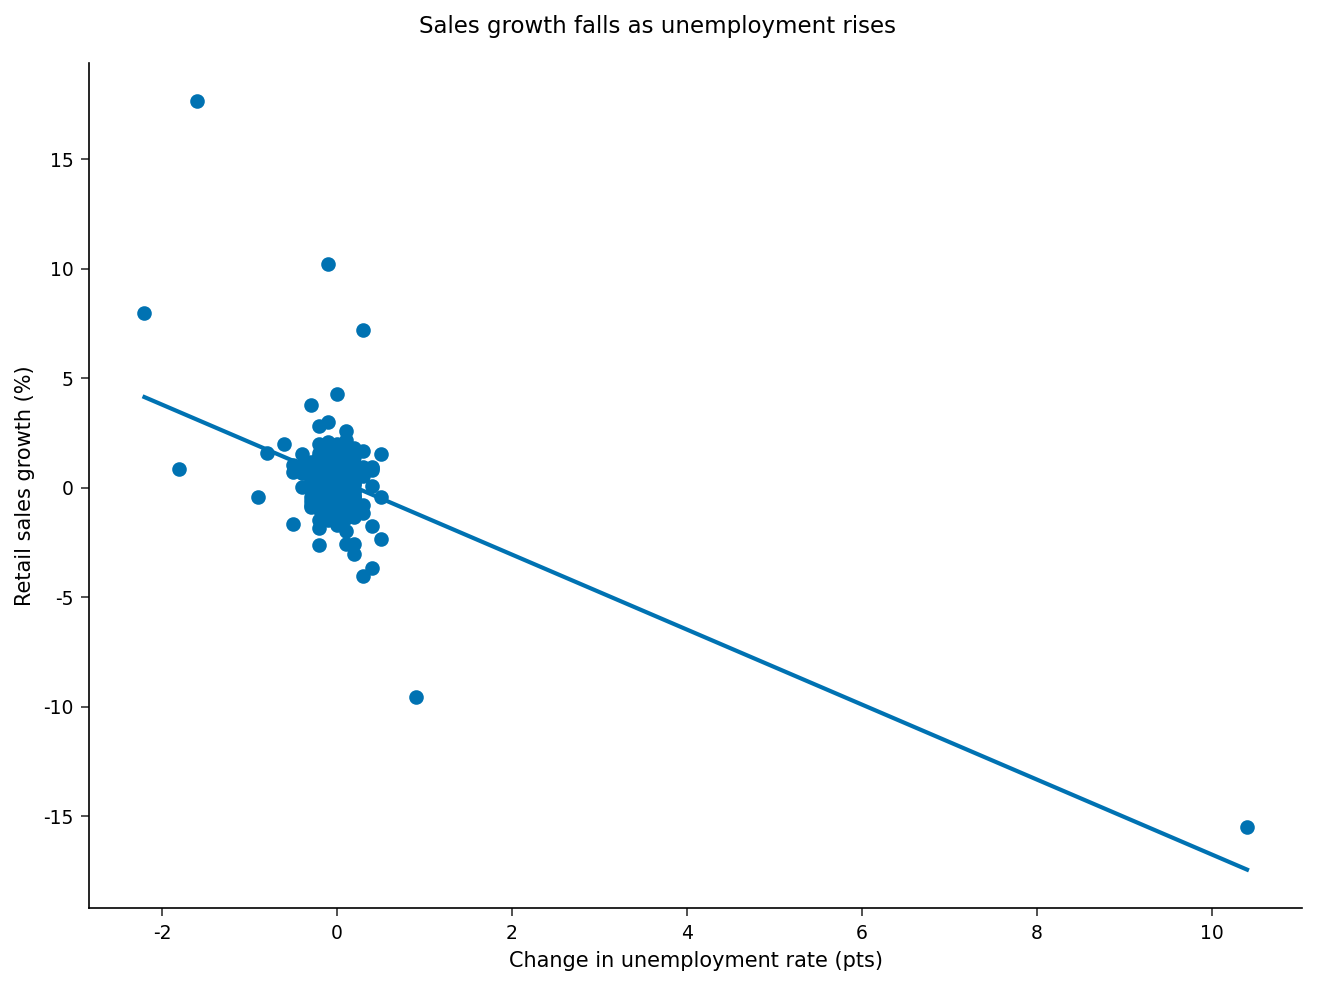

In [2]:
proc sgplot data="retail_x.csv";
    reg x=dunrate y=dlsales;
    xaxis label="Change in unemployment rate (pts)";
    yaxis label="Retail sales growth (%)";
    title "Sales growth falls as unemployment rises";
run;

## Step 3 - Fit the VARX(2) by least squares

Put the two growth series on the left so each gets an equation with
two lags of both; put `dunrate` on the right as the shared exogenous
regressor. `XLAG=0` keeps only the current change in unemployment, and
`METHOD=LS` fits each equation by ordinary least squares.

In [3]:
proc varmax data="retail_x.csv";
    model dlsales dlincome = dunrate
          / p=2 xlag=0 method=ls
            print=(estimates);
run;


                                                  The VARMAX Procedure                                                  

Model Type: VARX(2,0)
Number of Observations: 395
Dependent Variables: dlsales dlincome
AR Order (p): 2
MA Order (q): 0

Parameter Estimates
Parameter                Estimate    Std Error      t Value     Pr > |t|
---------                --------    ---------      -------     --------
L1.dlsales->dlsales     -0.296737     0.040628        -7.30       0.0000
L1.dlincome->dlsales     0.052475     0.044615         1.18       0.2395
L1.dlsales->dlincome    -0.180402     0.043567        -4.14       0.0000
L1.dlincome->dlincome    -0.566190     0.047842       -11.83       0.0000
L2.dlsales->dlsales     -0.187388     0.040029        -4.68       0.0000
L2.dlincome->dlsales     0.120352     0.043211         2.79       0.0053
L2.dlsales->dlincome    -0.085135     0.042925        -1.98       0.0473
L2.dlincome->dlincome    -0.062779     0.046336        -1.35       0.1755
Inte


NOTE: PROC VARMAX data=retail_x.csv

NOTE: Using Python (statsmodels VAR/VARMAX) for VARMAX estimation


## Reading the output

**The exogenous driver dominates.** In the sales equation,
`dunrate->dlsales` is about -1.99 (*t* = -16.2): when the unemployment
rate rises by a point in a month, retail-sales growth drops roughly
two points at once. In the income equation, `dunrate->dlincome` is
about +0.90 (*t* = 6.8) -- disposable income edges *up* as unemployment
climbs, consistent with transfer payments that cushion household
income during downturns. One shock, two opposite signs, both sharp.

**The autoregressive terms describe the month-to-month churn.** The
own-lag coefficients are negative (`L1.dlsales->dlsales` around -0.30,
`L1.dlincome->dlincome` around -0.57): a strong month tends to be
followed by a pullback, the usual mean reversion of monthly growth
rates. Income also propagates into spending with a delay --
`L2.dlincome->dlsales` is about 0.12 (*t* = 2.8), so an income gain
reaches the checkout line a couple of months later.

**Precision matters.** Read each estimate against its standard error;
the contemporaneous unemployment effect on sales is the single most
decisive term in the system.

## Interpreting the results

- **Spending is procyclical; income is buffered.** The same rise in
  unemployment that pulls retail-sales growth down by ~2 points nudges
  disposable-income growth *up* by ~0.9 -- automatic stabilizers at
  work. Modeling the two together makes the contrast explicit.
- **Short memory, quick reversion.** Negative own-lags say both series
  give back a strong month rather than compound it; these are growth
  rates, not levels.
- **Lagged pass-through.** Income feeds spending with about a
  two-month delay, a small but measurable channel.
- **Why `METHOD=LS`.** Least squares makes each equation an ordinary
  regression, matching how references such as R's `vars` report VARX
  coefficients -- handy when you need to reproduce a published table.